In [58]:
#importing libraries and datasets
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [63]:
data = fetch_california_housing(as_frame=True)
print(data)

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -1

In [64]:
X= data.data[['MedInc']]
y = data.target

In [65]:
print(X,y)

       MedInc
0      8.3252
1      8.3014
2      7.2574
3      5.6431
4      3.8462
...       ...
20635  1.5603
20636  2.5568
20637  1.7000
20638  1.8672
20639  2.3886

[20640 rows x 1 columns] 0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64


In [84]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Fitting a linear model

In [90]:
linear_reg = LinearRegression()
linear_reg.fit(X_train,y_train)
y_pred = linear_reg.predict(X_test)

In [91]:
poly = PolynomialFeatures(degree=3)
poly3d = poly.fit_transform(X_train)
polylin = LinearRegression()
polylin.fit(poly3d,y_train)
polytest = poly.fit_transform(X_test)
X_grid = np.linspace(
    X.min().values[0],
    X.max().values[0],
    500
).reshape(-1,1)

y_grid = polylin.predict(poly.transform(X_grid))

C:\Users\David\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


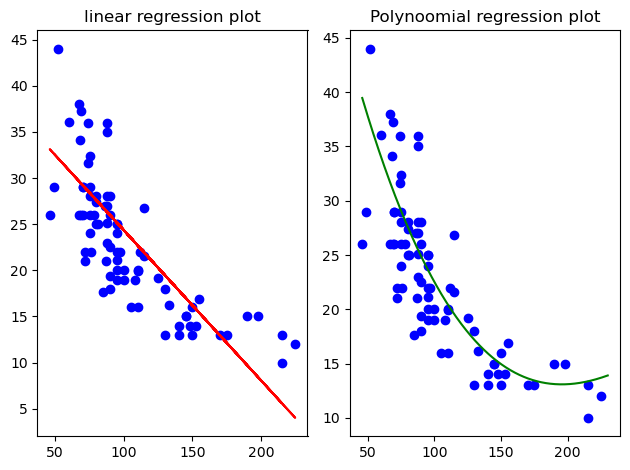

In [93]:
plt.subplot(1,2,1)
plt.scatter(X_test,y_test,color='blue')
plt.plot(X_test,y_pred,color='red')
plt.title("linear regression plot")
plt.subplot(1,2,2)
plt.scatter(X_test,y_test,color='blue')
plt.plot(X_grid, y_grid, color='green')
plt.title("Polynoomial regression plot")
plt.tight_layout()
plt.show()

In [70]:
print(f"Linear Regression- MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"Polynomial Regression- MSE: {mean_squared_error(y_test,ypolypred):.4f}")

Linear Regression- MSE: 0.7091
Polynomial Regression- MSE: 0.6983


========== LINEAR REGRESSION ==========
Linear Regression MSE: 46.144775347317264
Linear Regression R2 Score: 0.3707569232254778

========== POLYNOMIAL REGRESSION ==========


C:\Users\David\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Polynomial Regression MSE: 18.460267222059844
Polynomial Regression R2 Score: 0.6383217814086145


C:\Users\David\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


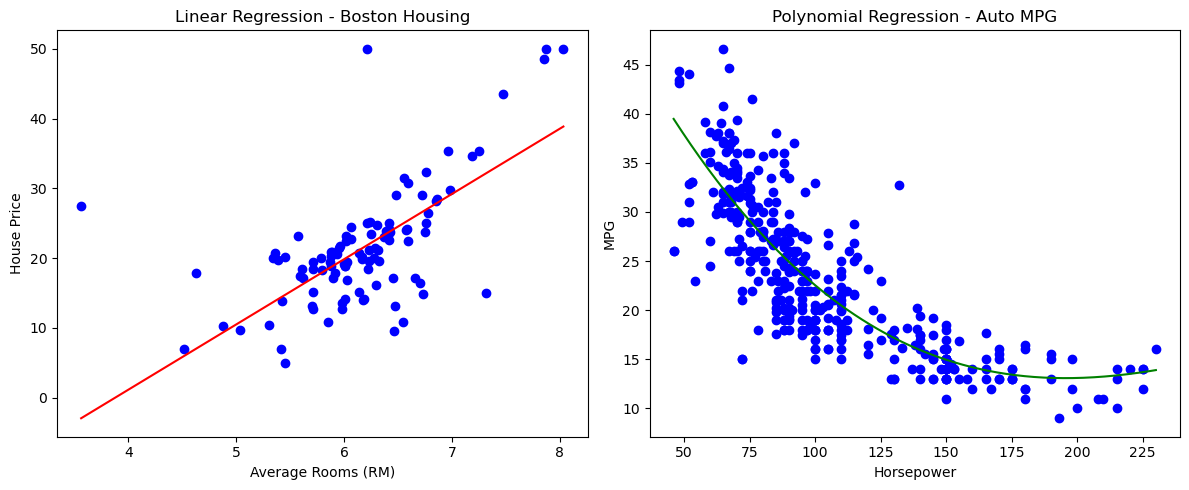

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_openml

# ==================================================
# LINEAR REGRESSION - BOSTON HOUSING DATASET
# ==================================================

print("========== LINEAR REGRESSION ==========")

boston = fetch_openml(name='boston', version=1, as_frame=True)

X = boston.data[['RM']]     # Average number of rooms
y = boston.target.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression MSE:", mse)
print("Linear Regression R2 Score:", r2)

# Plot
X_test_sorted = np.sort(X_test.values.flatten())
y_sorted = lin_reg.predict(X_test_sorted.reshape(-1,1))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test_sorted, y_sorted, color='red')
plt.title("Linear Regression - Boston Housing")
plt.xlabel("Average Rooms (RM)")
plt.ylabel("House Price")

# ==================================================
# POLYNOMIAL REGRESSION - AUTO MPG DATASET
# ==================================================

print("\n========== POLYNOMIAL REGRESSION ==========")

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

df = df[['horsepower', 'mpg']]
df.dropna(inplace=True)

X = df[['horsepower']]
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

y_poly_pred = poly_reg.predict(X_test_poly)

mse_poly = mean_squared_error(y_test, y_poly_pred)
r2_poly = r2_score(y_test, y_poly_pred)

print("Polynomial Regression MSE:", mse_poly)
print("Polynomial Regression R2 Score:", r2_poly)

# Smooth curve
X_grid = np.linspace(
    X.min().values[0],
    X.max().values[0],
    500
).reshape(-1,1)

y_grid = poly_reg.predict(poly.transform(X_grid))

plt.subplot(1,2,2)
plt.scatter(X, y, color='blue')
plt.plot(X_grid, y_grid, color='green')
plt.title("Polynomial Regression - Auto MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")

plt.tight_layout()
plt.show()

* learnt pretty basic modelling techniques like linear and polynomial regresson
* using the same california housing prices as boston house model was not available , but later accessed using fetch_openml functions
* where my model looks great now , the manual itself was wrong